All problem sets must be submitted as a Jupyter Notebook. You must organize your analysis and utilize the Notebook's markdown capabilities to present your solutions. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown.

## PART 1: ROSENBLATT'S ALGORITHM
    

Now we will consider how to train the perceptron so it can learn the weights automatically.

We have learned that the perceptron can only learn functions that are linearly separable: it will learn a line that separates the true values from the the false values, so if no such line exists, then the perceptron can't learn it!

To get started, we are going to generate some linearly separable data.  The code in the next cell generates such a dataset and plots it.

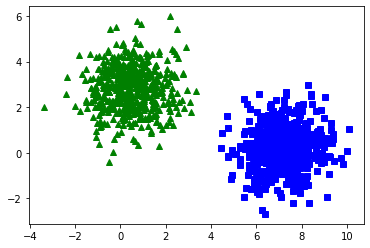

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(21)

X, y = datasets.make_blobs(n_samples=1000, centers=2, n_features=2, center_box=(0, 10))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.show()

## Question 1
🎒<font color='red'>(1 points)</font>

Show the shapes of X and y

((1000, 2), (1000,))

## Question 2
🎒<font color='red'>(1 points)</font>

Add a third column of ones to the dataset X.  

Create the column using the numpy function `np.ones(shape)`

Add the column using the numpy function append.  The "axis" argument tells the function which dimension to append to: are you adding a new block of data (axis=None), a new row (axis=0; will result in an error), or a new column (axis=1)?

(We could do all this with Dataframes too, but it works out to be simpler to just use raw arrays.)

## Question 3
🎒<font color='red'>(1 points)</font>

Initialize a vector of weights that are between 0 and 1. 

Also select a step size

Each row of the dataset X has three values: X1, X2, and bias.  

So we will need three weights.

Remember the perceptron will be computing the expression

    w1*X1 + w2*X2 + w3*bias

This expression corresponds to a line, which we can rewrite in slope-intercept form:

    X2 = w1/w2 * X1 + w3/w2

Set the initial weights, and plot your resulting line.

Your line probably does not separate the two blobs.  That's fine -- we're going to automatically adjust the weights  until it does separate them!  That's what Rosenblatt's algorithm does.

## Question 4
🎒<font color='red'>(8 points)</font>

You will now implement the myPerceptron function to implement your own learning procedure.  Pseudocode for the function body appears in the next cell.  


Some notes:

a) Create a function called myPerceptron that takes in the following four inputs: $X$, $Y$, a vector of weights, and your step size.

b) The function should pass through a single iteration of Rosenblatt's algorithm&mdash;we will run this function until convergence in the next question. 

This means we will handle the whole dataset, but only one time. We will make multiple passes over the dataset in the next question.

But in this question, you are implementing the myPerceptron function, not this outer loop.

c) The function should output two things every time it is called: the vector of updated weights and a count of the number of misclassifications. A function that returns two things looks like this:

    def somefunc(x):
        return x+1, x-1
        a, b = somefunc(x)

d) Implement the body of the function

Look at the [bottom of 4.9 for pseudocode for Rosenblatt's algorithm](https://canvas.uw.edu/courses/1576691/pages/4-dot-9-back-to-basics-nn-for-logistic-regression?module_item_id=15264372).


[This article](https://sebastianraschka.com/Articles/2015_singlelayer_neurons.html) provides much more detail, but be careful not to just copy and paste code; it will be difficult to retrofit to this assignment.

e) Note: Use a dot product operation to multiply the weight vector with the input matrix in calculations.  Make sure you understand what this means!

The inputs to a neuron are all added together: w1x1+ w2x2 + ... wnxn

That's the same operation as the dot product of a vector (w1, w2, ..., wn) and a vector (x1, x2, ..., xn)

If needed, review the [math fundamentals in 4.4](https://canvas.uw.edu/courses/1576691/pages/4-dot-4-math-fundamentals-review?module_item_id=15264367)

f) Note: keep in mind that $\hat{y}$ is a "raw" prediction and must be thresholded to 0 or 1 to be compared with the target value $y$.


<div class="alert alert-block alert-info">
errors = 0 
    
For each training example i from 1 to m:  
  &nbsp;&nbsp;&nbsp;&nbsp; let x = X[i], y = Y[i]  
  &nbsp;&nbsp;&nbsp;&nbsp; *# We're only working with the ith record*  
  
  
  &nbsp;&nbsp;&nbsp;&nbsp; $\hat{y} = (wx >= 0)$    
  &nbsp;&nbsp;&nbsp;&nbsp; *# Compute the predicted values for $y$*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# wx is the dot product of the weights w and the vector x, where x is the ith record in the dataset X*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# (wx >= 0) means every value greater than or equal to 0 becomes 1 and every value less 0 becomes 0*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# this is the "thresholding" step*  
  
  &nbsp;&nbsp;&nbsp;&nbsp; $\Delta w = \eta (y - \hat{y})x$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Calculate change in weight:*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# $\eta$ is the step size*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# $y$ is the true value (target) and $\hat{y}$ is the prediction we just computed above.*   
  &nbsp;&nbsp;&nbsp;&nbsp; *# Take their difference, multiply by step size, and multiply that by the vector x*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Check: What is the shape of $\Delta w$?*  
        
  &nbsp;&nbsp;&nbsp;&nbsp; w = w + $\Delta w$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Update weights*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Now adjust the weights: the new weights = the old weights + the changes to the weights*  
 
  &nbsp;&nbsp;&nbsp;&nbsp; if $y \neq \hat{y}$ then $\text{errors} = \text{errors} + 1$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Compute the error: If the prediction was wrong for this record, then add one to the count of errors*  
  
return w, errors  
*# Now we're done and we can return the adjusted weights and the accumulated errors*  
 </div>

## Question 5
🎒<font color='red'>(4 points)</font>

Run your myPerceptron function using your starting weights and step size until convergence. 

One possible structure for this is to wrap it in a while loop:

    (Initialize weights here)
    while errors:
        weights, errors = myPerceptron(X, y, weights, step)
        

Once finished, plot the number of errors for each iteration vs. the iteration number. (You'll need to keep track of the errors at each step so you can plot them.)

How many iterations did the function take to converge? What does the shape of the plot of the errors look like? Do you think gradient descent would generate a plot of errors vs. iteration (epoch) that looks similar? Why or why not?

## Question 6
🎒<font color='red'>(1 points)</font>

The values of your weights after convergence can be used to draw a separation line where:

$$
w_{1} x_{1}+w_{2} x_{2}+w_{3} x_{3}=0 \\
$$

Consider your plot from Q1. We want to superimpose the separation line that we calculated onto the plot. Solve the equation above for whichever variable is on the y-axis of the plot from Q1, be it $X_1$ or $X_2$.


In other words, solve the equation above such that you have something of the form `y = mx + b`, where $y$ is the variable on the y-axis of the plot from Q1 and $x$ is the variable on the x-axis. 

<div class="alert alert-block alert-info">
Remember that $X_{0}$ is our bias term of 1 and $w_{0} X_{0}$ is therefore a constant. 
</div>

Plot this line onto a copy of your plot from Q1 and comment on what you see.

## PART 2: OUT-OF-THE-BOX NEURAL NETWORKS 

In part 3, we will build a multi-layer network.  As we've seen, a single layer network can learn linearly separable datasets, and we saw in the online material that they can *only* learn linearly separable data.  But we need complex, curvy boundaries to separate the classes -- real data is complex and has many dimensions.   

But now we won't bother implementing the network and learning process by hand. We will use the libraries provided for us. 

You now know how the training process works for a simple network: Calculate an adjustment to the weights based on the difference between the true value and the predicted value, apply the adjustment, and repeat until there are no more errors.  In general, this process involves computing the *derivative* of the objective function: find the direction to adjust the weights that lead the biggest decrease in error.   We roll the ball downhill to find a point where the error is minimized.  Another difference: The "error" will not necessarily converge; you can't always get rid of all errors.  So "convergence" will be something the algorithm will estimate.  It might be that if you trained a little longer, the error might go down, or it might not.  You eventually just have to say that the current model is "good enough."   

## Question 7
🎒<font color='red'>(1 points)</font>

Import the [california housing dataset](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html) from sklearn.


## Question 8
🎒<font color='red'>(1 points)</font>

Plot the data to see what we're working with.

x-axis: Latitude

y-axis: Longitude

color: medianvalue

The result should be roughly in the shape of the state of California.

## Question 9
🎒<font color='red'>(1 points)</font>

Create a new binary variable `highpriced` that indicates whether the house is greater than \$200,000

The target `MedHouseVal` gives the price in hundreds of thousands of dollars, so you want values of `MedHouseVal` > 2

## Question 10
🎒<font color='red'>(1 points)</font>

Create a training/test split for the california dataset.  Use sklearn [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  Pass `california.data` as the X values and your new `highpriced` variable as the y values.

Use the `test_size` parameter to control how big the test set will be; assume 0.2.

You can also use the `random_state` parameter to make sure you get the same results every time.

show the shape of the result X_test and y_test.  They should be (4128, 8) and (4128,) respectively.

## Question 11
🎒<font color='red'>(3 points)</font>

Now use [`sklearn.MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) to train a model.

MLP stands for multilayer perceptron.   Classifier means we will be predicting whether each house is high priced or not.

Use the parameter `hidden_layer_sizes` to control both how many layers your model will have and how many neurons per layer.

The  parameter `hidden_layer_sizes` takes a tuple of integers.  For example,  `hidden_layer_sizes=(4,6)` means a two layer model with 4 neurons in the first layer and 6 neurons in the second layer.

Also set `max_iter=1000` just in case your model doesn't converge; we don't want it to train forever.

Report the accuracy on both training and test by calling the score method of the trained model.

    print('Training accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_train, y_train)))
    print('Testing accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_test, y_test)))


## Question 12
🎒<font color='red'>(2 points)</font>

Train several models for different architectures: vary the number of layers and number of neurons and see how high you can get.  Show the accuracy for all the models you tried.  Which is best?

In [179]:

# few layers, few neurons

# more layers, more neurons

# etc.

## Question 13
🎒<font color='red'>(1 points)</font>

Show a plot of where your model tends to make mistakes for your best model.  Plot latitude and longitude, but color the points by whether the prediction matches the ground truth.  

Comment on what you see -- are they geographical patterns to the errors?

## Question 14: Reflection
🎒<font color='red'>(4 points)</font>

In Part 1, we studied how a simple neural network computes its results, and configured results by hand.

In Part 2, we trained the model automatically by writing a training procedure by hand.

In Part 3, we used a library to set up the model and train it with just a few lines of code.

Reflect on your results overall by considering the following questions:

* Part 1: Do you feel you understand how neural networks compute the answer?  Why were these single-layer networks studied originally?  What was their main limitation?

* Part 2: Do you feel you understand how training works?  How does the model learn to get better results?

* Part 3: What kinds of architectures worked well in Part 3?  Why do you think that is?  What are some ways we might improve results?  What additional data might we want to collect to make the model better?




`write your response here`